In [1]:
#https://huggingface.co/learn/diffusion-course/en/unit1/2

import os
from dotenv import load_dotenv
from huggingface_hub import login

# Load environment variables from the .env file
load_dotenv()

# Option A: Login explicitly using the loaded environment variable
login(token=os.environ.get("HF_TOKEN"))

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image


def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from diffusers import StableDiffusionPipeline

# Check out https://huggingface.co/sd-dreambooth-library for loads of models from the community
model_id = "sd-dreambooth-library/mr-potato-head"

# Load the pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(
    device
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/carl/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/carl/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/carl/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/carl/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [4]:
# prompt = "an abstract oil painting of sks mr potato head by picasso"
# image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
# image

In [5]:
# prompt = "an abstract oil painting of mr potato head by picasso"
# image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
# image

In [6]:
# prompt = "an abstract oil painting of sks mr potato head by picasso"
# image = pipe(prompt, num_inference_steps=25, guidance_scale=7.5).images[0]
# image

In [7]:
# prompt = "an abstract oil painting of sks mr potato head by picasso"
# image = pipe(prompt, num_inference_steps=50, guidance_scale=1).images[0]
# image

In [8]:
# prompt = "an abstract oil painting of sks mr potato head by picasso"
# image = pipe(prompt, num_inference_steps=50, guidance_scale=30).images[0]
# image

In [9]:
# prompt = "an abstract oil painting of sks mr potato head by picasso"
# image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
# image

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/carl/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3: Error no file named diffusion_pytorch_model.safetensors found in directory /home/carl/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

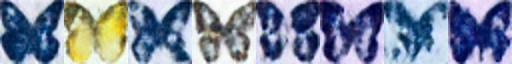

In [10]:
from diffusers import DDPMPipeline

# Load the butterfly pipeline
butterfly_pipeline = DDPMPipeline.from_pretrained(
    "johnowhitaker/ddpm-butterflies-32px"
).to(device)

# Create 8 images
images = butterfly_pipeline(batch_size=8).images

# View the result
make_grid(images)

In [11]:
import torchvision
from datasets import load_dataset
from torchvision import transforms

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

# Or load images from a local folder
# dataset = load_dataset("imagefolder", data_dir="path/to/folder")

# We'll train on 32-pixel square images, but you can try larger sizes too
image_size = 32
# You can lower your batch size if you're running out of GPU memory
batch_size = 64

# Define data augmentations
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

Repo card metadata block was not found. Setting CardData to empty.


X shape: torch.Size([8, 3, 32, 32])


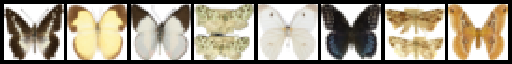

In [12]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 64, 64), resample=Image.NEAREST)

In [13]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

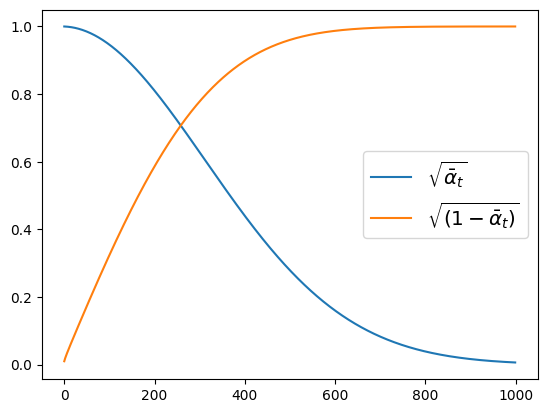

In [14]:
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

Noisy X shape torch.Size([8, 3, 32, 32])


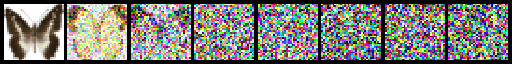

In [15]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 64, 64), resample=Image.NEAREST)

In [16]:
from diffusers import UNet2DModel

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device);

In [17]:
with torch.no_grad():
    model_prediction = model(noisy_xb, timesteps).sample
model_prediction.shape

torch.Size([8, 3, 32, 32])

In [18]:
# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# # Training loop
# optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

# losses = []

# for epoch in range(30):
#     for step, batch in enumerate(train_dataloader):
#         clean_images = batch["images"].to(device)
#         # Sample noise to add to the images
#         noise = torch.randn(clean_images.shape).to(clean_images.device)
#         bs = clean_images.shape[0]

#         # Sample a random timestep for each image
#         timesteps = torch.randint(
#             0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
#         ).long()

#         # Add noise to the clean images according to the noise magnitude at each timestep
#         noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

#         # Get the model prediction
#         noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

#         # Calculate the loss
#         loss = F.mse_loss(noise_pred, noise)
#         loss.backward(loss)
#         losses.append(loss.item())

#         # Update the model parameters with the optimizer
#         optimizer.step()
#         optimizer.zero_grad()

#     if (epoch + 1) % 5 == 0:
#         loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
#         print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

In [19]:
# fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# axs[0].plot(losses)
# axs[1].plot(np.log(losses))
# plt.show()

In [20]:
model = butterfly_pipeline.unet

In [21]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)

  0%|          | 0/1000 [00:00<?, ?it/s]

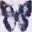

In [22]:
pipeline_output = image_pipe()
pipeline_output.images[0]

In [23]:
image_pipe.save_pretrained("my_pipeline")

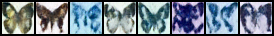

In [24]:
# Random starting point (8 random images):
sample = torch.randn(8, 3, 32, 32).to(device)

for i, t in enumerate(noise_scheduler.timesteps):

    # Get model pred
    with torch.no_grad():
        residual = model(sample, t).sample

    # Update sample with step
    sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample)

In [25]:
from huggingface_hub import get_full_repo_name

model_name = "sd-class-butterflies-32"
hub_model_id = get_full_repo_name(model_name)
hub_model_id

'dogfish-thinker/sd-class-butterflies-32'

In [26]:
from huggingface_hub import create_repo,HfApi
from huggingface_hub.errors import RepositoryNotFoundError


api = HfApi()

# create_repo(
#     repo_id=hub_model_id,
#     exist_ok=True,
# )

try:
    api.repo_info(hub_model_id)
    print(f"{hub_model_id} already exists.")
except RepositoryNotFoundError:
    create_repo(hub_model_id)
    print(f"Created {hub_model_id}.")

api.upload_folder(
    folder_path="my_pipeline/scheduler", path_in_repo="", repo_id=hub_model_id
)
api.upload_folder(folder_path="my_pipeline/unet", path_in_repo="", repo_id=hub_model_id)
api.upload_file(
    path_or_fileobj="my_pipeline/model_index.json",
    path_in_repo="model_index.json",
    repo_id=hub_model_id,
)

dogfish-thinker/sd-class-butterflies-32 already exists.


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/dogfish-thinker/sd-class-butterflies-32/commit/9aa667dcbc7af7b071f433665549e7f330e8ba6e', commit_message='Upload model_index.json with huggingface_hub', commit_description='', oid='9aa667dcbc7af7b071f433665549e7f330e8ba6e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/dogfish-thinker/sd-class-butterflies-32', endpoint='https://huggingface.co', repo_type='model', repo_id='dogfish-thinker/sd-class-butterflies-32'), pr_revision=None, pr_num=None)

In [27]:
from huggingface_hub import ModelCard

content = f"""
---
license: mit
tags:
- pytorch
- diffusers
- unconditional-image-generation
- diffusion-models-class
---

# Model Card for Unit 1 of the [Diffusion Models Class 🧨](https://github.com/huggingface/diffusion-models-class)

This model is a diffusion model for unconditional image generation of cute 🦋.

## Usage

```python
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained('{hub_model_id}')
image = pipeline().images[0]
image
"""

card = ModelCard(content)
card.push_to_hub(hub_model_id)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/dogfish-thinker/sd-class-butterflies-32/commit/9aa667dcbc7af7b071f433665549e7f330e8ba6e', commit_message='Upload README.md with huggingface_hub', commit_description='', oid='9aa667dcbc7af7b071f433665549e7f330e8ba6e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/dogfish-thinker/sd-class-butterflies-32', endpoint='https://huggingface.co', repo_type='model', repo_id='dogfish-thinker/sd-class-butterflies-32'), pr_revision=None, pr_num=None)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

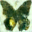

In [28]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline.from_pretrained(hub_model_id)
pipeline_output = image_pipe()
pipeline_output.images[0]

In [29]:
# !wget https://github.com/huggingface/diffusers/raw/main/examples/unconditional_image_generation/train_unconditional.py

--2026-08-03 15:07:50--  https://github.com/huggingface/diffusers/raw/main/examples/unconditional_image_generation/train_unconditional.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/huggingface/diffusers/main/examples/unconditional_image_generation/train_unconditional.py [following]
--2026-08-03 15:07:52--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/unconditional_image_generation/train_unconditional.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31274 (31K) [text/plain]
Saving to: ‘train_unconditional.py’

train_unconditional 100%[===================>]  30.

In [33]:
# Let's give our new model a name for the Hub
model_name = "sd-class-butterflies-64"
hub_model_id = get_full_repo_name(model_name)
hub_model_id

'dogfish-thinker/sd-class-butterflies-64'

In [35]:
!accelerate launch train_unconditional.py \
  --dataset_name="huggan/smithsonian_butterflies_subset" \
  --resolution=64 \
  --output_dir={model_name} \
  --train_batch_size=32 \
  --num_epochs=50 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-4 \
  --lr_warmup_steps=500 \
  --mixed_precision="no"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
08/03/2026 15:39:17 - INFO - __main__ - [RANK 0] Distributed environment: NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

08/03/2026 15:39:19 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/datasets/huggan/smithsonian_butterflies_subset/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
08/03/2026 15:39:19 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/huggan/smithsonian_butterflies_subset/3cdedf844922ab40393d46d4c7f81c596e1c6d45/README.md "HTTP/1.1 200 OK"
08/03/2026 15:39:19 - INFO - httpx - HTTP Reque

In [36]:
create_repo(hub_model_id, exist_ok=True)
api = HfApi()
api.upload_folder(
    folder_path=f"{model_name}/scheduler", path_in_repo="", repo_id=hub_model_id
)
api.upload_folder(
    folder_path=f"{model_name}/unet", path_in_repo="", repo_id=hub_model_id
)
api.upload_file(
    path_or_fileobj=f"{model_name}/model_index.json",
    path_in_repo="model_index.json",
    repo_id=hub_model_id,
)

content = f"""
---
license: mit
tags:
- pytorch
- diffusers
- unconditional-image-generation
- diffusion-models-class
---

# Model Card for Unit 1 of the [Diffusion Models Class 🧨](https://github.com/huggingface/diffusion-models-class)

This model is a diffusion model for unconditional image generation of cute 🦋.

## Usage

```python
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained('{hub_model_id}')
image = pipeline().images[0]
image
"""
card = ModelCard(content)
card.push_to_hub(hub_model_id)

CommitInfo(commit_url='https://huggingface.co/dogfish-thinker/sd-class-butterflies-64/commit/bd973d6aa96c5fef0cd26a33aaed5b06ff8df8da', commit_message='Upload README.md with huggingface_hub', commit_description='', oid='bd973d6aa96c5fef0cd26a33aaed5b06ff8df8da', pr_url=None, repo_url=RepoUrl('https://huggingface.co/dogfish-thinker/sd-class-butterflies-64', endpoint='https://huggingface.co', repo_type='model', repo_id='dogfish-thinker/sd-class-butterflies-64'), pr_revision=None, pr_num=None)

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

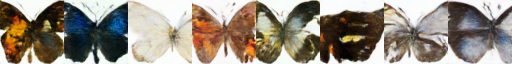

In [37]:
pipeline = DDPMPipeline.from_pretrained(hub_model_id).to(device)
images = pipeline(batch_size=8).images
make_grid(images)